# Initial EDA - R.O.A.D. Barbados Historic Handwriting Challenge

Purpose:

- Inspect train/test/submission files.
- Validate image availability for every ID.
- Understand target text length, vocabulary, and character set.
- Inspect image sizes and visual quality.
- Produce enough context to design the first OCR baseline.

## 0. Setup

Run this notebook from anywhere. It resolves paths relative to the project root.

In [1]:
import os
from pathlib import Path
from collections import Counter
import json
import random
import re

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 100)

def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    candidates = [start, *start.parents]
    for path in candidates:
        if (path / "data").exists() and (path / "src").exists():
            return path
    raise FileNotFoundError("Could not find project root with data/ and src/ directories.")

PROJECT_ROOT = find_project_root()
RAW_ROOT = PROJECT_ROOT / "data" / "raw"
RAW_DIR = RAW_ROOT / "road-barbados-historic-handwriting-challenge"
IMAGE_DIR = RAW_ROOT / "images"

TRAIN_PATH = RAW_DIR / "Train.csv"
TEST_PATH = RAW_DIR / "Test.csv"
SUBMISSION_PATH = RAW_DIR / "SampleSubmission.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data dir: {RAW_DIR}")
print(f"Image dir: {IMAGE_DIR}")

Matplotlib is building the font cache; this may take a moment.


Project root: /home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records
Raw data dir: /home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/road-barbados-historic-handwriting-challenge
Image dir: /home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images


In [2]:
for path in [TRAIN_PATH, TEST_PATH, SUBMISSION_PATH, IMAGE_DIR]:
    print(f"{path.name:>22}: exists={path.exists()} path={path}")

             Train.csv: exists=True path=/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/road-barbados-historic-handwriting-challenge/Train.csv
              Test.csv: exists=True path=/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/road-barbados-historic-handwriting-challenge/Test.csv
  SampleSubmission.csv: exists=True path=/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/road-barbados-historic-handwriting-challenge/SampleSubmission.csv
                images: exists=True path=/home/furqan/Documents/competitive data science/build-models-to-transcribe-handwritten-historical-records/data/raw/images


## 1. Load CSV files

In [3]:
# utf-8-sig handles a possible BOM in Test.csv.
train = pd.read_csv(TRAIN_PATH, encoding="utf-8-sig")
test = pd.read_csv(TEST_PATH, encoding="utf-8-sig")
sample_submission = pd.read_csv(SUBMISSION_PATH, encoding="utf-8-sig")

print("train:", train.shape)
print("test:", test.shape)
print("sample_submission:", sample_submission.shape)

display(train.head(10))
display(test.head(10))
display(sample_submission.head(10))

train: (4098, 2)
test: (1374, 1)
sample_submission: (1374, 2)


,ID,Target
0,uGI8F9Er0c5XwdnX,By this publique Act and Instrument of protest
1,Dqt2gc3V5RJqmLE5,By this publique Act and Instrument of protest
2,eqF93vAKYa4aOeHr,By this public act and Instrument of protest be it known
3,SEYEZ7fwp3MbYkkB,By this public act and Instrument of protest be it known
4,sQjpjiUTThaMf4j6,By this public act and Instrument of protest be it
5,Zer3bZ5I7YFGoqS6,By this public Act and Instrument of protest be it
6,xD0EIkxQ5xUJIjuV,of February In the year of our Lord God one thousand six hundred sixty
7,vIO1Vk2ZKi0Yn0Sz,of February in the Year of our Lord God one thousand six hundred sixty
8,0mbbbshnl0XReeqC,of February in the year of our Lord God one thousand six hundred sixty
9,8kn3TLDy8Pzkhxre,date the Sixth day of July One thousand Six hundred


,ID
0,MzQuRiUbPFsq6Azy
1,1LrXN25dFz88Spt3
2,voWkMuyhO8FAlLr5
3,iQqdWwQ7uXrATwei
4,fdbPL2qsoaciDFoi
5,nEnN2tNfiPuI0eKo
6,Z7TfVaawKoiQZOO7
7,WhALleExeDgpxSQj
8,myxl7VamCxHmaLtv
9,wH9GBIhd2kvngi9L


,ID,Target
0,MzQuRiUbPFsq6Azy,luythisenlo h
1,1LrXN25dFz88Spt3,uecessarieo
2,voWkMuyhO8FAlLr5,NaN
3,iQqdWwQ7uXrATwei,NaN
4,fdbPL2qsoaciDFoi,Y88
5,nEnN2tNfiPuI0eKo,4ohn gonnu hi ksyror Bxo
6,Z7TfVaawKoiQZOO7,ne sndale sabterSoenefres
7,WhALleExeDgpxSQj,Naluabls rontidrs
8,myxl7VamCxHmaLtv,WwMee
9,wH9GBIhd2kvngi9L,NaN


In [4]:
def dataframe_overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    return pd.DataFrame({
        "dataset": name,
        "column": df.columns,
        "dtype": [df[col].dtype for col in df.columns],
        "missing": [df[col].isna().sum() for col in df.columns],
        "missing_pct": [df[col].isna().mean() for col in df.columns],
        "nunique": [df[col].nunique(dropna=True) for col in df.columns],
    })

overview = pd.concat([
    dataframe_overview(train, "train"),
    dataframe_overview(test, "test"),
    dataframe_overview(sample_submission, "sample_submission"),
], ignore_index=True)

display(overview)

for name, df in [("train", train), ("test", test), ("sample_submission", sample_submission)]:
    if "ID" in df.columns:
        print(f"{name}: duplicate ID count = {df['ID'].duplicated().sum()}")

,dataset,column,dtype,missing,missing_pct,nunique
0,train,ID,str,0,0.00000,4098
1,train,Target,str,0,0.00000,4086
2,test,ID,str,0,0.00000,1374
3,sample_submission,ID,str,0,0.00000,1374
4,sample_submission,Target,str,346,0.25182,1011


train: duplicate ID count = 0
test: duplicate ID count = 0
sample_submission: duplicate ID count = 0


## 2. Image inventory and ID consistency

In [5]:
image_paths = sorted(IMAGE_DIR.glob("*.jpg"))
image_ids = {path.stem for path in image_paths}
train_ids = set(train["ID"].astype(str))
test_ids = set(test["ID"].astype(str))
submission_ids = set(sample_submission["ID"].astype(str))

print(f"Number of images: {len(image_paths):,}")
print(f"Train IDs: {len(train_ids):,}")
print(f"Test IDs: {len(test_ids):,}")
print(f"Sample submission IDs: {len(submission_ids):,}")
print(f"Train/Test overlap: {len(train_ids & test_ids):,}")
print(f"Sample submission matches test: {submission_ids == test_ids}")

missing_train_images = sorted(train_ids - image_ids)
missing_test_images = sorted(test_ids - image_ids)
extra_images = sorted(image_ids - (train_ids | test_ids))

print(f"Missing train images: {len(missing_train_images):,}")
print(f"Missing test images: {len(missing_test_images):,}")
print(f"Extra images not referenced by train/test: {len(extra_images):,}")

if missing_train_images[:10]:
    print("Example missing train image IDs:", missing_train_images[:10])
if missing_test_images[:10]:
    print("Example missing test image IDs:", missing_test_images[:10])
if extra_images[:10]:
    print("Example extra image IDs:", extra_images[:10])

Number of images: 5,472
Train IDs: 4,098
Test IDs: 1,374
Sample submission IDs: 1,374
Train/Test overlap: 0
Sample submission matches test: True
Missing train images: 0
Missing test images: 0
Extra images not referenced by train/test: 0


## 3. Target text EDA

In [7]:
target = train["Target"].fillna("").astype(str)

train_text = train.copy()
train_text["char_len"] = target.str.len()
train_text["word_len"] = target.str.split().str.len()
train_text["lower_target"] = target.str.lower()

display(train_text[["char_len", "word_len"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

print(f"Empty target rows: {(train_text['char_len'] == 0).sum():,}")
print(f"Unique exact targets: {train_text['Target'].nunique(dropna=True):,}")
print(f"Duplicated exact target rows: {train_text['Target'].duplicated().sum():,}")

display(train_text.sort_values("char_len").head(15)[["ID", "Target", "char_len", "word_len"]])
display(train_text.sort_values("char_len", ascending=False).head(15)[["ID", "Target", "char_len", "word_len"]])

,char_len,word_len
count,4098.000000,4098.000000
mean,62.278184,11.275988
std,12.705858,2.656333
min,37.000000,4.000000
1%,40.000000,6.000000
5%,43.000000,7.000000
25%,52.000000,9.000000
50%,62.000000,11.000000
75%,71.000000,13.000000
95%,85.000000,16.000000


Empty target rows: 0
Unique exact targets: 4,086
Duplicated exact target rows: 12


,ID,Target,char_len,word_len
2507,wT4VIBQqeDPI7ju8,Fran Smith John Edward Ellis Steele.,37,6
1422,C9K4ImPGDT7fQpvw,in the prsence of us Richard Holdipp,37,7
3570,3ZxOeKcOr5wUYyk0,x x x bound benige first x x x x x x x,38,13
2098,IV1mn6z8vNWCtF4c,p:sone or p:sones whatsoever; In Witt-,38,6
229,DmBEKU1M4df04aiP,"Thomas x^ Sign Vyntton, Richard Credge",38,6
3327,z9B6NB4pQnZ1ITZK,Charles Wilson. ye mk of W^m Russell -,38,8
2907,Wa3GYoo8H4i1VywB,"and his Heires forever, eighteen Acres",38,6
233,hKEIOZXLyI4eiyzA,"Deed, the said Elizabeth acknowledging",38,5
896,Z4R7IsiBH3x1hF9L,signed and delivered in the prsence of,38,7
29,R3i1amI9QDkg6ihX,Sealed and delivered in the prsence of,38,7


,ID,Target,char_len,word_len
1258,t0UrASljcgzvBAnO,1681 Murphey Marcous of the Parrish of St.Phillips in the -- Island aforesaid sends greeting in our Lord God everlasting,120,20
2756,tQAuzSsJimAQ8yRV,Barbados To all Xpian people to whome theise pnts presents shall come William Readye of the Island aforesaid,108,18
788,PuDCCRnGEY59YVkQ,Judgements wherein he is bound to Robert Harrison by the first day of May next dated y^e 15^th Aprill 1642,106,20
53,fsGQONvf08WpRtoZ,executors or assynes the sume of Eight thousand pounds of the like tobaccoe in manner and forme followinge,106,18
510,XBolZ9SHDdJp62hD,or cause to be notified by mee or any other person or persons that noe debters pay or cause to be paid,102,22
2655,iZDQHJMu8W5CN0U5,trees lyeing groweing or fallen together with all profits and benefitts thereunto belonging or in any,101,16
2919,GB16JC5kV3ECqWp1,that in case the abovesaid one ~hundred~ thousand two hundred and thirty pounds of cotton to be paid,100,18
2058,IDAdn1Ay5XL8Sb24,and Francis Pearson with all profitts and commodities thereunto belonging or any wyse appertayneinge,100,14
3235,OrXXHFOprCeTsprv,Januar: 1640 Barbados planter sendeth greeting in our Lord God Everlasting Knowe yee that I the said,100,17
2620,pRIf9rapdPFuu82M,and aldormen of y^e City of London have caused the Seale of y^e office of Majorasty of y^e same City,100,20


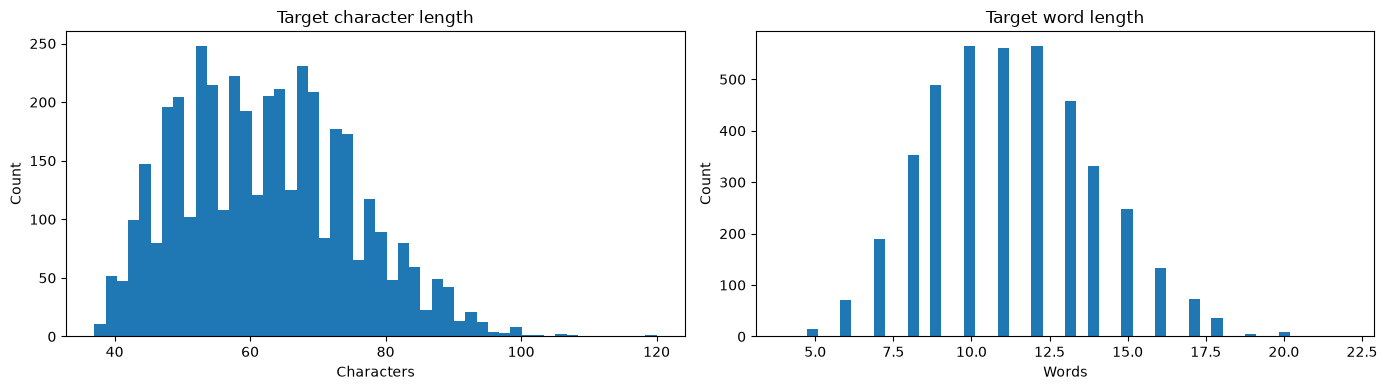

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(train_text["char_len"], bins=50)
axes[0].set_title("Target character length")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

axes[1].hist(train_text["word_len"], bins=50)
axes[1].set_title("Target word length")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [9]:
all_text = "\n".join(target.tolist())
char_counts = Counter(all_text)
word_counts = Counter(re.findall(r"\b\S+\b", all_text.lower()))

print(f"Unique characters: {len(char_counts):,}")
print("Unique characters repr:")
print(" ".join(repr(ch) for ch in sorted(char_counts)))

char_df = pd.DataFrame(char_counts.most_common(), columns=["char", "count"])
char_df["repr"] = char_df["char"].map(repr)
display(char_df[["repr", "count"]].head(50))

word_df = pd.DataFrame(word_counts.most_common(50), columns=["word", "count"])
display(word_df)

Unique characters: 82
Unique characters repr:
'\n' ' ' '"' '#' '&' "'" '(' ')' '*' '+' ',' '-' '.' '0' '1' '2' '3' '4' '5' '6' '7' '8' '9' ':' ';' '?' 'A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W' 'X' 'Y' '\\' '^' '_' 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r' 's' 't' 'u' 'v' 'w' 'x' 'y' 'z' '|' '~'


,repr,count
0,' ',42278
1,'e',27879
2,'a',16998
3,'t',16291
4,'o',15764
5,'n',15676
6,'s',13748
7,'r',13147
8,'i',11499
9,'d',11030


,word,count
0,and,2668
1,the,2642
2,of,2282
3,to,1119
4,or,1073
5,in,814
6,said,803
7,all,542
8,by,452
9,for,424


In [10]:
target_counts = train_text["Target"].value_counts(dropna=False).reset_index()
target_counts.columns = ["Target", "count"]
display(target_counts.head(30))

,Target,count
0,Sealed and delivered in the prsence of,3
1,Sealed and delivered in the presence of,3
2,By this publique Act and Instrument of protest,2
3,By this public act and Instrument of protest be it known,2
4,date the Sixth day of July One thousand Six hundred,2
5,Signed Sealed and delivered in the presence of us,2
6,This done and protested the day and year aforesaid,2
7,To all Christian People to whome this present writeing shall come,2
8,To all Christian People to whome these presents shall,2
9,for or by reason of the said Whiston not loading of the said twelve,2


## 4. Image dimensions and corrupt image checks

In [12]:
records = []
bad_images = []

for path in image_paths:
    try:
        with Image.open(path) as img:
            width, height = img.size
            mode = img.mode
        records.append({"ID": path.stem, "path": str(path), "width": width, "height": height, "mode": mode})
    except Exception as exc:
        bad_images.append({"path": str(path), "error": repr(exc)})

image_meta = pd.DataFrame(records)
if not image_meta.empty:
    image_meta["aspect_ratio"] = image_meta["width"] / image_meta["height"]
    image_meta["area"] = image_meta["width"] * image_meta["height"]

print(f"Readable images: {len(image_meta):,}")
print(f"Bad/corrupt images: {len(bad_images):,}")
if bad_images:
    display(pd.DataFrame(bad_images).head(20))

display(image_meta[["width", "height", "aspect_ratio", "area"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))
display(image_meta["mode"].value_counts().rename_axis("mode").reset_index(name="count"))

Readable images: 5,472
Bad/corrupt images: 0


,width,height,aspect_ratio,area
count,5472.000000,5472.000000,5472.000000,5.472000e+03
mean,1914.286367,136.069993,17.107340,4.458371e+05
std,1471.438780,132.755822,4.962653,6.825508e+05
min,267.000000,28.000000,3.034091,1.966800e+04
1%,615.710000,39.000000,8.196132,3.566475e+04
5%,938.550000,43.000000,9.708515,4.407410e+04
25%,1065.000000,51.000000,13.005224,5.442975e+04
50%,1119.000000,65.000000,16.784144,6.946450e+04
75%,2815.500000,214.250000,21.133370,7.977600e+05
95%,4912.900000,404.000000,25.102872,1.882686e+06


,mode,count
0,RGB,5472


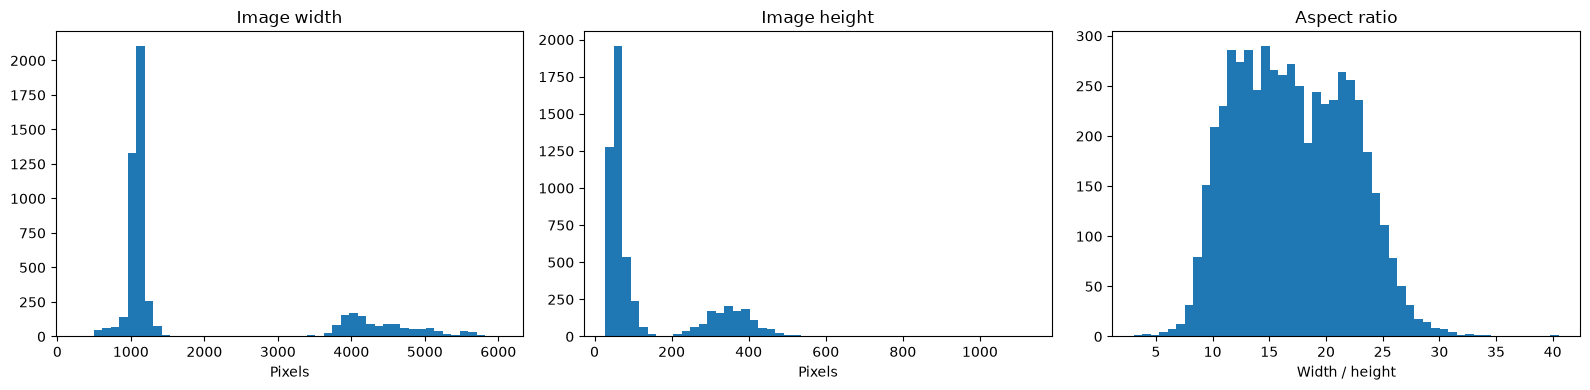

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(image_meta["width"], bins=50)
axes[0].set_title("Image width")
axes[0].set_xlabel("Pixels")

axes[1].hist(image_meta["height"], bins=50)
axes[1].set_title("Image height")
axes[1].set_xlabel("Pixels")

axes[2].hist(image_meta["aspect_ratio"], bins=50)
axes[2].set_title("Aspect ratio")
axes[2].set_xlabel("Width / height")

plt.tight_layout()
plt.show()

Train image metadata missing rows: 0
Test image metadata missing rows: 0


,char_len,word_len,width,height,aspect_ratio
char_len,1.000000,0.841353,-0.124329,-0.226228,0.379861
word_len,0.841353,1.000000,-0.116800,-0.208732,0.354612
width,-0.124329,-0.116800,1.000000,0.949029,-0.460725
height,-0.226228,-0.208732,0.949029,1.000000,-0.625971
aspect_ratio,0.379861,0.354612,-0.460725,-0.625971,1.000000


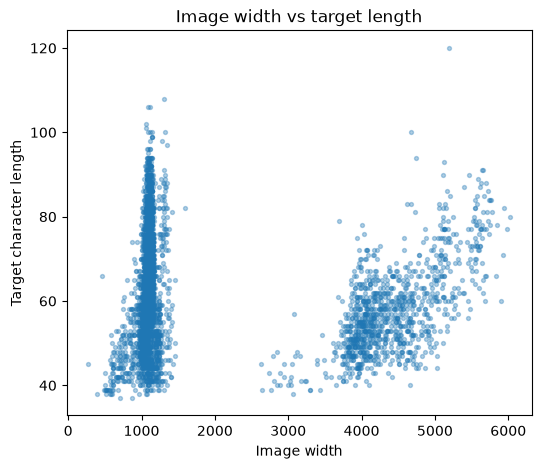

In [14]:
train_meta = train_text.merge(image_meta.drop(columns=["path"], errors="ignore"), on="ID", how="left")
test_meta = test.merge(image_meta.drop(columns=["path"], errors="ignore"), on="ID", how="left")

print("Train image metadata missing rows:", train_meta["width"].isna().sum())
print("Test image metadata missing rows:", test_meta["width"].isna().sum())

display(train_meta[["char_len", "word_len", "width", "height", "aspect_ratio"]].corr(numeric_only=True))

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(train_meta["width"], train_meta["char_len"], s=8, alpha=0.35)
ax.set_xlabel("Image width")
ax.set_ylabel("Target character length")
ax.set_title("Image width vs target length")
plt.show()

## 5. Visual samples

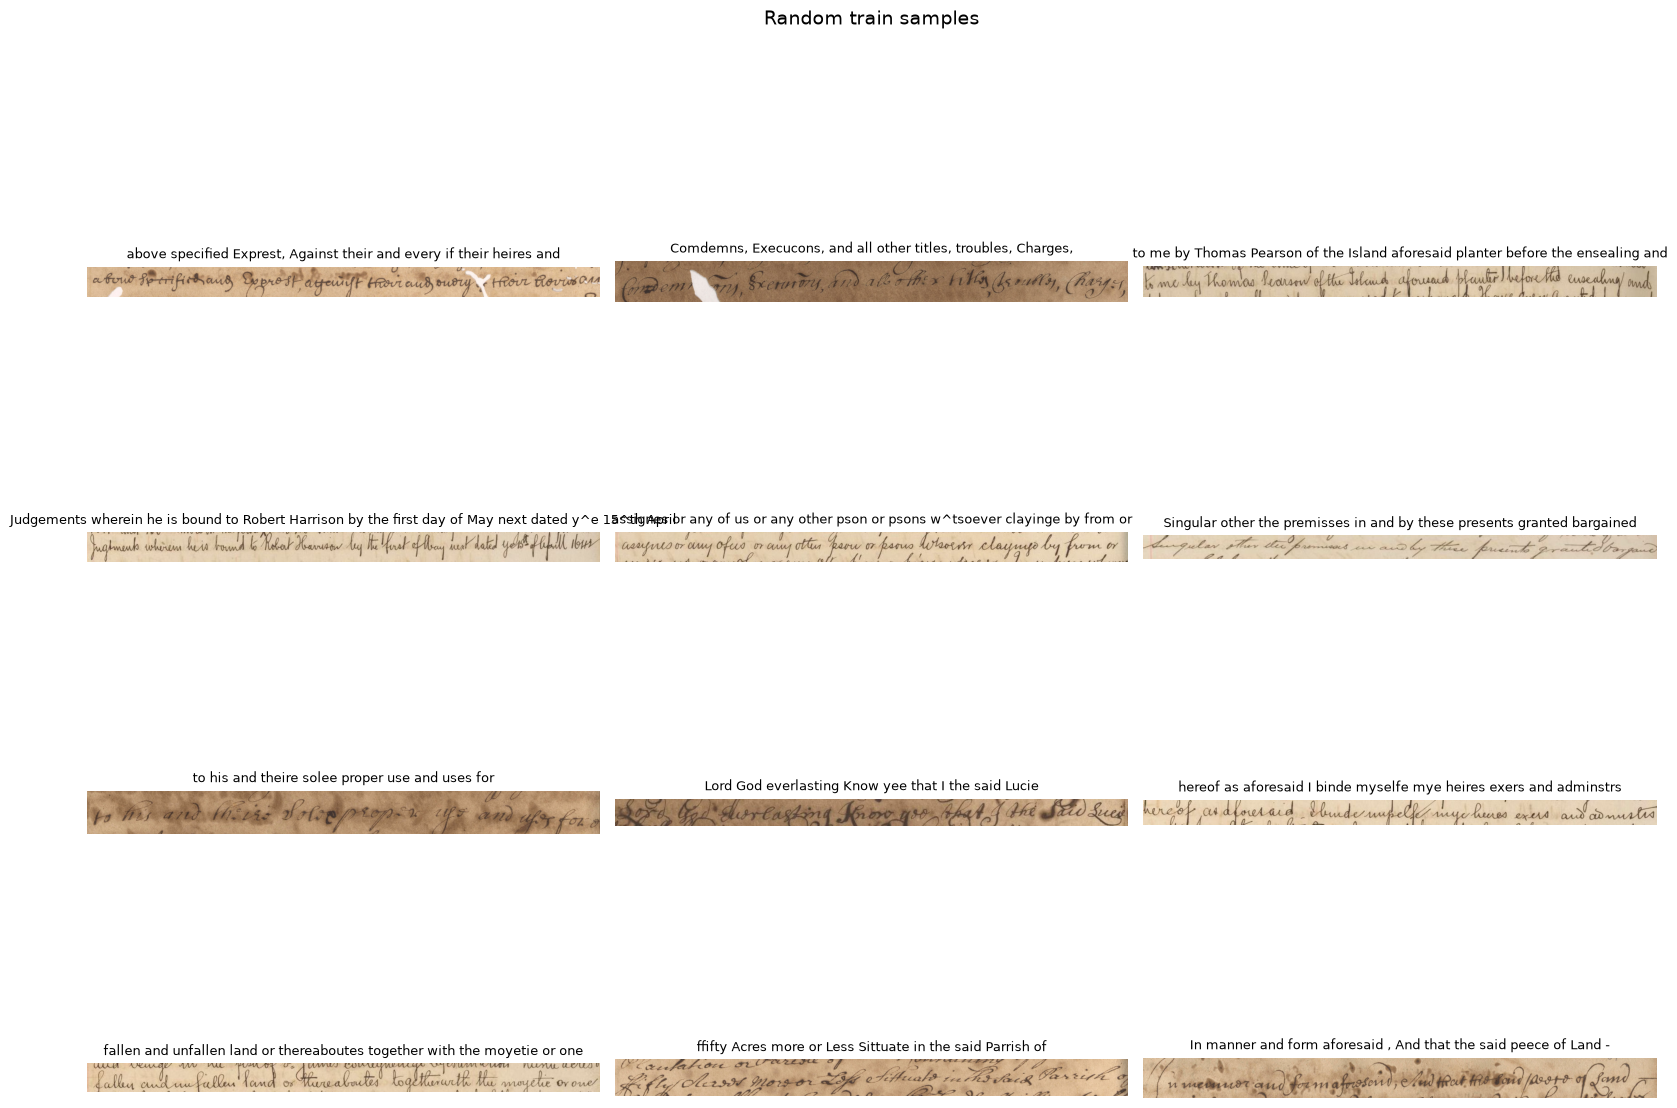

In [15]:
def show_samples(df: pd.DataFrame, title: str, n: int = 12, seed: int = 42) -> None:
    sample = df.dropna(subset=["ID"]).sample(min(n, len(df)), random_state=seed)
    ncols = 3
    nrows = int(np.ceil(len(sample) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
    axes = np.atleast_1d(axes).ravel()
    fig.suptitle(title, y=1.01, fontsize=14)

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img_path = IMAGE_DIR / f"{row['ID']}.jpg"
        with Image.open(img_path) as img:
            ax.imshow(img.convert("RGB"))
        label = row.get("Target", "")
        ax.set_title(str(label)[:100], fontsize=9)
        ax.axis("off")

    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train, "Random train samples", n=12, seed=7)

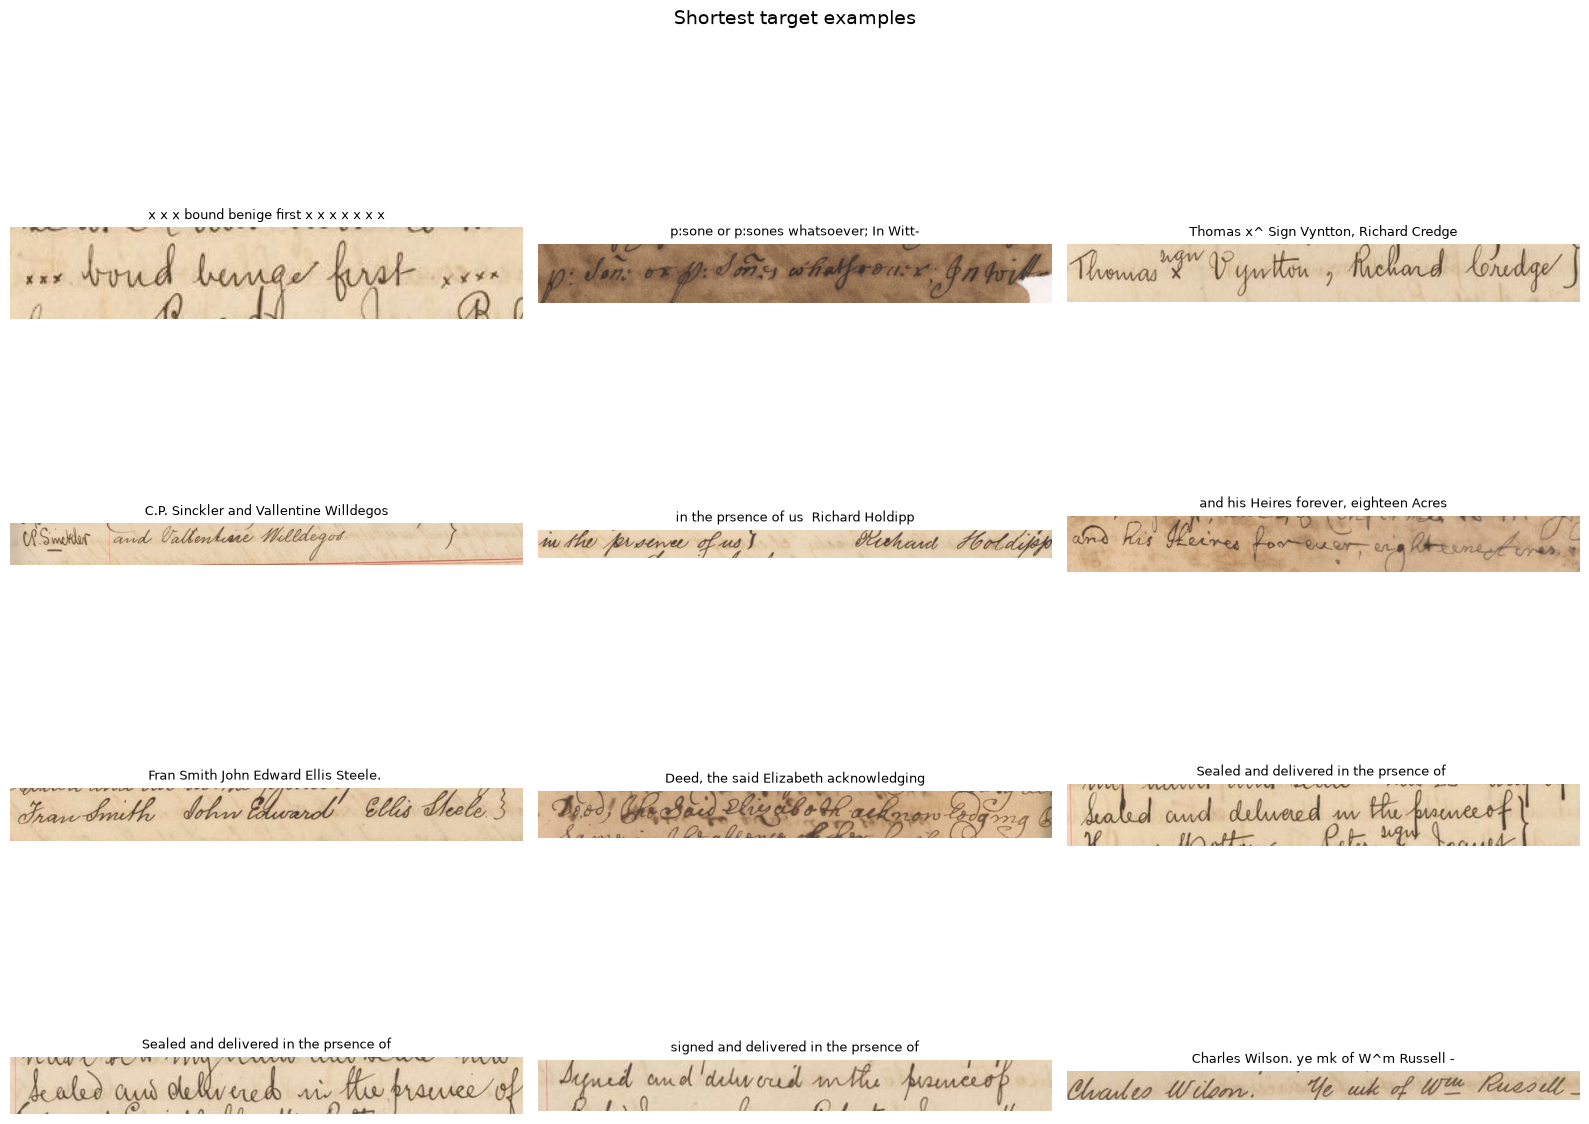

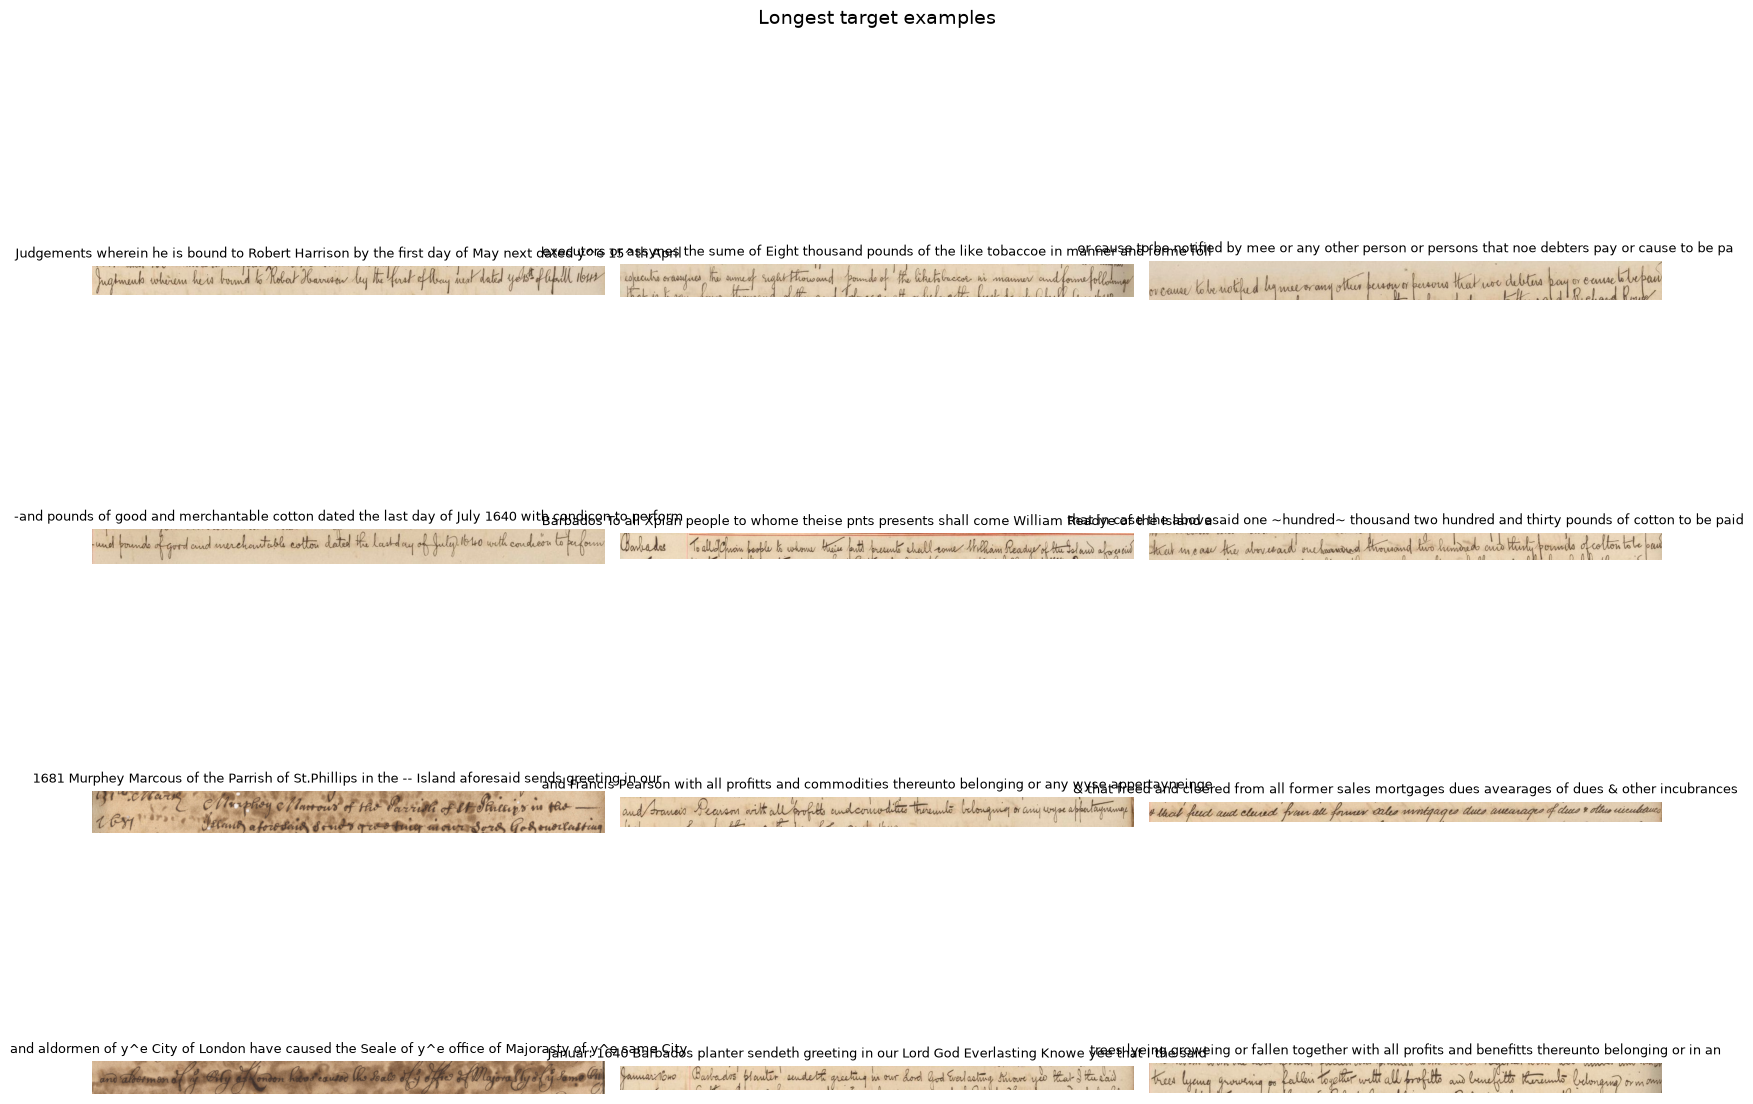

In [16]:
short_examples = train_meta.sort_values("char_len").head(12)
long_examples = train_meta.sort_values("char_len", ascending=False).head(12)

show_samples(short_examples, "Shortest target examples", n=12, seed=1)
show_samples(long_examples, "Longest target examples", n=12, seed=1)

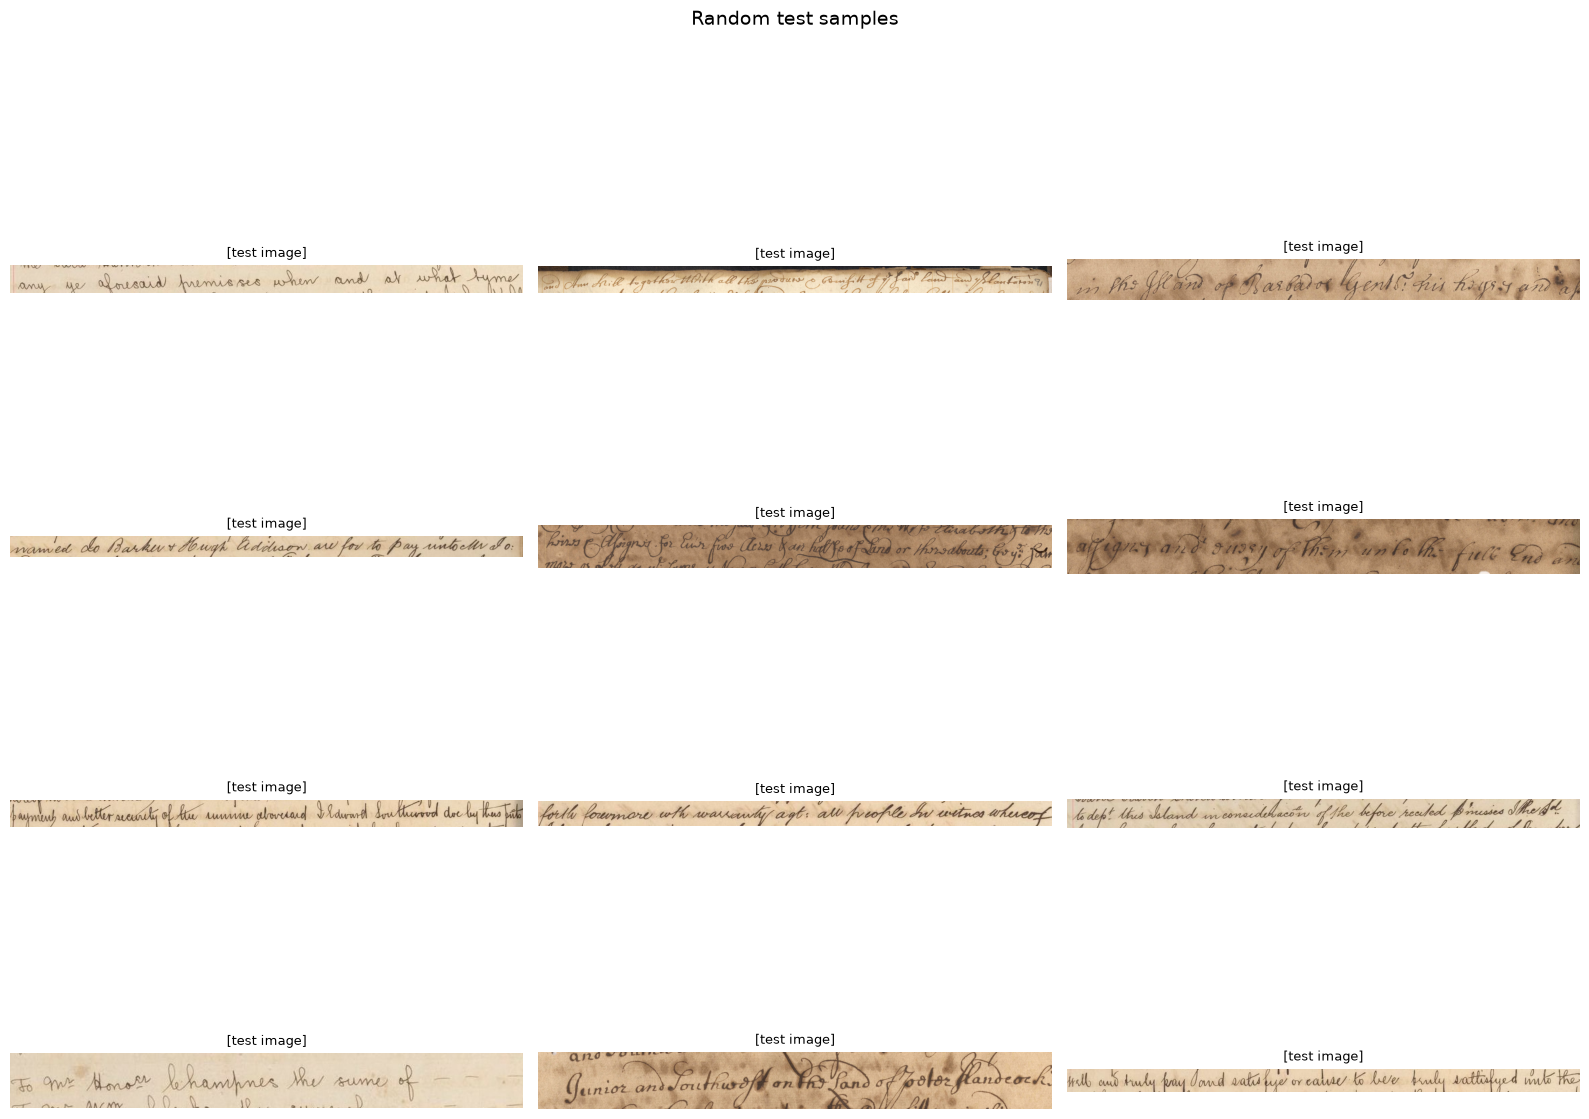

In [17]:
test_display = test.copy()
test_display["Target"] = "[test image]"
show_samples(test_display, "Random test samples", n=12, seed=13)

## 6. Summary for next step

After running all cells, copy or screenshot these outputs for discussion:

- Dataset shapes and missing values.
- ID/image consistency report.
- Target length stats and unique characters.
- Image dimension stats.
- A few visual sample grids.

In [18]:
summary = {
    "n_train": int(len(train)),
    "n_test": int(len(test)),
    "n_images": int(len(image_paths)),
    "missing_train_images": int(len(missing_train_images)),
    "missing_test_images": int(len(missing_test_images)),
    "extra_images": int(len(extra_images)),
    "target_char_len_min": int(train_text["char_len"].min()),
    "target_char_len_median": float(train_text["char_len"].median()),
    "target_char_len_max": int(train_text["char_len"].max()),
    "target_word_len_median": float(train_text["word_len"].median()),
    "unique_characters": len(char_counts),
    "bad_images": len(bad_images),
}

print(json.dumps(summary, indent=2))

{
  "n_train": 4098,
  "n_test": 1374,
  "n_images": 5472,
  "missing_train_images": 0,
  "missing_test_images": 0,
  "extra_images": 0,
  "target_char_len_min": 37,
  "target_char_len_median": 62.0,
  "target_char_len_max": 120,
  "target_word_len_median": 11.0,
  "unique_characters": 82,
  "bad_images": 0
}
